In [1]:
# Core
import pandas as pd
import numpy as np
import random
import re

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_text_image_only finall .csv to tmdb_text_image_only finall  (3).csv


In [3]:
import pandas as pd

df = pd.read_csv("tmdb_text_image_only finall .csv")

print(df.head())
print(df.shape)

                                   overview_enhanced   label  tmdb_id  \
0  have you ever done a handstand on the tips of ...  Action    68902   
1  when the head of a notorious crime family is m...  Action  1096563   
2  jack santos is a retired undercover vice cop w...  Action  1102332   
3  cassie the last remaining member of the origin...  Action    89828   
4  in a timeless city a man with no name returns ...  Action    19206   

                              title                       poster_path  
0            Shaolin: Wheel of Life  /jJdCMsK9QAP4BMP2I9GYBnjx93f.jpg  
1                    End of Loyalty  /c4QA1rFQcyBZKaOOdUrDeL1G9Er.jpg  
2                        Jack's Law  /qKxC5DXUhgKwRxmyBHDC8muWoly.jpg  
3  Gang of Roses 2: Next Generation  /g6KGKjw74YSfdmYpXI5IEbVr0OJ.jpg  
4                 The Perfect Sleep  /zv46BDUwdMjnj4evC8q3j7j95VM.jpg  
(8128, 5)


In [4]:
import re
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

TEXT_COL = "overview_enhanced"
LABEL_COL = "label"

# =========================
#  Better cleaning
# =========================
def clean_text(text):
    text = str(text).lower()

    # keep numbers (important for movies)
    text = re.sub(r"[^a-zA-Z0-9 ]", "", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text


df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

# =========================
# split texts + labels
# =========================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df[TEXT_COL].values,
    df[LABEL_COL].values,
    test_size=0.1,
    random_state=42
)

# =========================
# tokenizer (train only)
# =========================
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# =========================
# sequences
# =========================
train_seq = tokenizer.texts_to_sequences(train_texts)
val_seq = tokenizer.texts_to_sequences(val_texts)

X_train = pad_sequences(train_seq, maxlen=100, padding="post", truncating="post")
X_val = pad_sequences(val_seq, maxlen=100, padding="post", truncating="post")

print(X_train.shape, X_val.shape)


(7315, 100) (813, 100)


In [13]:
import numpy as np

def create_pairs(texts, labels, num_pairs=8000):

    pairs = []
    pair_labels = []

    labels = np.array(labels)

    unique_labels = np.unique(labels)

    label_to_indices = {
        label: np.where(labels == label)[0]
        for label in unique_labels
    }

    for _ in range(num_pairs):

        # ======================
        # Positive Pair
        # ======================

        label = np.random.choice(unique_labels)

        idx1, idx2 = np.random.choice(
            label_to_indices[label],
            2,
            replace=False
        )

        pairs.append([texts[idx1], texts[idx2]])
        pair_labels.append(1)

        # ======================
        # Hard Negative Pair
        # ======================

        neg_label = np.random.choice(
            unique_labels[unique_labels != label]
        )

        idx3 = np.random.choice(label_to_indices[label])

        neg_candidates = label_to_indices[neg_label]

        idx4 = np.random.choice(neg_candidates)

        pairs.append([texts[idx3], texts[idx4]])
        pair_labels.append(0)

    pairs = np.array(pairs)
    pair_labels = np.array(pair_labels)

    idx = np.random.permutation(len(pairs))

    return pairs[idx], pair_labels[idx]

In [14]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class PositionalEncoding(Layer):
    def __init__(self, max_len, d_model):
        super().__init__()

        self.pos_emb = Embedding(
            input_dim=max_len,
            output_dim=d_model
        )

    def call(self, x):

        seq_len = tf.shape(x)[1]

        positions = tf.range(0, seq_len, 1)

        pos = self.pos_emb(positions)

        return x + pos

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, Dense, Layer


class TransformerEncoder(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2):
        super(TransformerEncoder, self).__init__()

        # =========================
        #  Multi-head attention
        # =========================
        self.att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )

        # =========================
        #  Feed Forward Network (Improved)
        # =========================
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim),
            tf.keras.layers.Activation(tf.nn.gelu),
            Dropout(rate),
            Dense(embed_dim),
        ])

        # =========================
        #  Layer Norm (pre-norm improves stability)
        # =========================
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)

        # =========================
        #  Dropout
        # =========================
        self.drop1 = Dropout(rate)
        self.drop2 = Dropout(rate)

        #  Extra stability (important fix)
        self.drop_att = Dropout(rate)

    def call(self, inputs, training=False):

        # =========================
        #  Pre-Norm Attention (important upgrade)
        # =========================
        norm_inputs = self.norm1(inputs)

        attn = self.att(norm_inputs, norm_inputs)

        attn = self.drop_att(attn, training=training)

        # Residual connection
        x = inputs + attn

        # =========================
        #  Pre-Norm Feed Forward
        # =========================
        norm_x = self.norm2(x)

        ffn_output = self.ffn(norm_x)

        ffn_output = self.drop2(ffn_output, training=training)

        # Final residual
        return x + ffn_output

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Dense,
    Dropout,
    LayerNormalization,
    GlobalMaxPooling1D
)
from tensorflow.keras.models import Model

VOCAB_SIZE = 20000
MAX_LEN = 100
EMBED_DIM = 128


# =========================
# Positional Encoding
# =========================
class PositionalEncoding(tf.keras.layers.Layer):

    def __init__(self, max_len, d_model):
        super().__init__()

        self.pos_emb = Embedding(
            input_dim=max_len,
            output_dim=d_model
        )

        #  IMPORTANT
        self.supports_masking = True

    def call(self, x):

        seq_len = tf.shape(x)[1]

        positions = tf.range(
            start=0,
            limit=seq_len,
            delta=1
        )

        positions = self.pos_emb(positions)

        return x + positions

    #  preserve mask
    def compute_mask(self, inputs, mask=None):
        return mask


# =========================
# Encoder Builder
# =========================
def build_encoder():

    inputs = Input(shape=(MAX_LEN,))

    # =========================
    # Embedding
    # =========================
    x = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        mask_zero=True
    )(inputs)

    # =========================
    # Positional Encoding
    # =========================
    x = PositionalEncoding(
        MAX_LEN,
        EMBED_DIM
    )(x)

    # =========================
    # Transformer Blocks
    # =========================
    x = TransformerEncoder(
        EMBED_DIM,
        4,
        256
    )(x)

    x = TransformerEncoder(
        EMBED_DIM,
        4,
        256
    )(x)

    # =========================
    # Stabilization
    # =========================
    x = LayerNormalization()(x)

    x = Dropout(0.2)(x)

    # =========================
    # Better Pooling
    # =========================
    x = GlobalMaxPooling1D()(x)

    # =========================
    # Projection Head
    # =========================
    x = Dense(
        256,
        activation="gelu"
    )(x)

    x = Dropout(0.2)(x)

    x = Dense(
        128,
        activation="gelu"
    )(x)

    x = Dropout(0.2)(x)

    # =========================
    # Final L2 Normalize
    # =========================
    outputs = tf.keras.layers.Lambda(
        lambda t: tf.nn.l2_normalize(
            t,
            axis=1
        )
    )(x)

    return Model(
        inputs,
        outputs,
        name="SemanticEncoder"
    )


# =========================
# Build Model
# =========================
encoder = build_encoder()

encoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_2' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "SemanticEncoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ (None, 100, 128)       │        12,800 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 100, 128)       │       132,480 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, 100, 128)       │       132,480 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_9           │ (None, 100, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,903,936 (11.08 MB)

 Trainable params: 2,903,936 (11.08 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Lambda
from tensorflow.keras.models import Model

# =========================
#  Inputs
# =========================
input_a = Input(shape=(MAX_LEN,))
input_b = Input(shape=(MAX_LEN,))

# =========================
#  Shared Encoder
# =========================
emb_a = encoder(input_a)
emb_b = encoder(input_b)

# =========================
#  Cosine Distance (stable version)
# =========================
def cosine_distance(vects):
    x, y = vects

    # normalize embeddings
    x = tf.nn.l2_normalize(x, axis=1)
    y = tf.nn.l2_normalize(y, axis=1)

    # cosine similarity → distance
    similarity = tf.reduce_sum(x * y, axis=1, keepdims=True)

    # clamp for numerical stability
    similarity = tf.clip_by_value(similarity, -1.0, 1.0)

    return 1.0 - similarity


distance = Lambda(cosine_distance, name="cosine_distance")([emb_a, emb_b])

# =========================
#  semantic Model
# =========================
semantic_model = Model([input_a, input_b], distance, name="semantic model")

semantic_model.summary()

Model: "semantic model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SemanticEncoder     │ (None, 128)       │  2,903,936 │ input_layer_10[0… │
│ (Functional)        │                   │            │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cosine_distance     │ (None, 1)         │          0 │ SemanticEncoder[… │
│ (Lambda)            │                   │            │ SemanticEncoder[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,903,936 (11.08 MB)

 Trainable params: 2,903,936 (11.08 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import tensorflow as tf

def contrastive_loss(margin=2.0, pos_weight=1.0, neg_weight=1.0):
    def loss(y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)

        # stability
        y_pred = tf.clip_by_value(y_pred, 1e-6, 2.0)

        # positive (pull together)
        positive_loss = y_true * tf.square(y_pred)

        # negative (push apart)
        neg_dist = tf.maximum(margin - y_pred, 0.0)
        negative_loss = (1 - y_true) * tf.square(neg_dist)

        # balanced normalization (IMPORTANT FIX)
        pos = tf.reduce_sum(positive_loss) / (tf.reduce_sum(y_true) + 1e-8)
        neg = tf.reduce_sum(negative_loss) / (tf.reduce_sum(1 - y_true) + 1e-8)

        return pos_weight * pos + neg_weight * neg

    return loss

In [20]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# =========================
# Create Training Pairs
# =========================
pairs, pair_labels = create_pairs(
    X_train,
    train_labels,
    num_pairs=8000
)

# =========================
# Split Pair Inputs
# =========================
X1 = pairs[:, 0]
X2 = pairs[:, 1]

print("X1 shape:", X1.shape)
print("X2 shape:", X2.shape)
print("Labels shape:", pair_labels.shape)

# =========================
# Better Contrastive Loss
# =========================
def contrastive_loss(margin=1.0):

    def loss(y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)

        # positive pairs
        positive_loss = y_true * tf.square(y_pred)

        # negative pairs
        negative_loss = (1 - y_true) * tf.square(
            tf.maximum(margin - y_pred, 0)
        )

        # final loss
        return tf.reduce_mean(
            positive_loss + negative_loss
        )

    return loss

# =========================
# Compile Model
# =========================
semantic_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=contrastive_loss(margin=1.0)
)

# =========================
# Callbacks
# =========================
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# =========================
# Train
# =========================
history = semantic_model.fit(

    [X1, X2],
    pair_labels,

    validation_split=0.1,

    epochs=8,

    batch_size=64,

    shuffle=True,

    callbacks=callbacks
)

X1 shape: (16000, 100)
X2 shape: (16000, 100)
Labels shape: (16000,)
Epoch 1/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - loss: 0.2574 - val_loss: 0.3661 - learning_rate: 1.0000e-04
Epoch 2/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - loss: 0.1798 - val_loss: 0.1787 - learning_rate: 1.0000e-04
Epoch 3/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - loss: 0.1344 - val_loss: 0.1839 - learning_rate: 1.0000e-04
Epoch 4/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - loss: 0.1284 - val_loss: 0.1640 - learning_rate: 1.0000e-04
Epoch 5/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - loss: 0.0991 - val_loss: 0.1016 - learning_rate: 1.0000e-04
Epoch 6/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - loss: 0.0802 - val_loss: 0.0987 - learning_rate: 1.0000e-04
Epoch 7/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - loss: 0.0774 - val_loss: 0.1000 - learning_rate: 1.0000e-04
Epoch 8/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0784
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.9999998736893

In [28]:
# =========================
# Generate Embeddings
# =========================
movie_embeddings = encoder.predict(
    X_train,
    batch_size=128
)

# =========================
# Normalize
# =========================
movie_embeddings = tf.nn.l2_normalize(
    movie_embeddings,
    axis=1
).numpy()

print(movie_embeddings.shape)

58/58 ━━━━━━━━━━━━━━━━━━━━ 30s 528ms/step
(7315, 128)


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(movie_embeddings)
print(similarity_matrix.shape)

(7315, 7315)


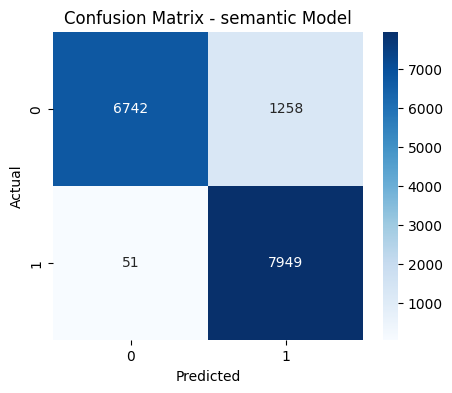

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(pair_labels, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - semantic Model")
plt.show()

In [41]:
import numpy as np
import pandas as pd

emb_df = pd.DataFrame(movie_embeddings)
emb_df.to_csv("movie_embeddings.csv", index=False)